# 实验：各类 Norm 的横向对比

本实验通过 4 个维度对 `core/norm/` 中已实现的 6 种归一化方案进行直观比较：

1. **3D 空间分布**：观察 norm 对三维点云的几何形变；
2. **深度信号传播**：模拟 50 层"纯 norm 网络"中均值与方差的演化；
3. **极端值压缩**：测试离群输入下的输出边界行为；
4. **延迟与参数量**：真实尺寸张量上的前向耗时与参数统计。

> **注意**：DeepNorm 的接口为 `forward(x, sublayer_out)`，本实验用固定的小型随机张量模拟子层输出，以与其他 norm 保持可比性。

In [26]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from mpl_toolkits.mplot3d import Axes3D

# 自动定位项目根目录
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / "pyproject.toml").exists()), None)
if repo_root is None:
    raise RuntimeError("未定位到项目根目录。请切换到仓库根目录后重试。")
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from core.norm import (
    RMSNorm, ScaleNorm, DeepNorm, DyT, Derf, get_deepnorm_constants
)

torch.manual_seed(42)
np.random.seed(42)

print("当前工作目录:", Path.cwd())
print("PyTorch version:", torch.__version__)

当前工作目录: D:\codingProgram\LLM-Walk-Through
PyTorch version: 2.4.0+cu118


In [27]:
DIM = 3

# 统计归一化 + 非线性替代
ln = nn.LayerNorm(DIM, elementwise_affine=True)
rms = RMSNorm(DIM)
scale = ScaleNorm(DIM, g=1.0)
dyt = DyT(DIM, use_gamma=True)
derf = Derf(DIM, use_gamma=True)

# DeepNorm 需要固定 sublayer 输出以参与横向比较
alpha = get_deepnorm_constants(12, arch_type="decoder")[0]
deep = DeepNorm(DIM, alpha=alpha)
# 预生成一个固定的模拟子层输出（小幅度随机扰动）
torch.manual_seed(7)
deep_sublayer_template = torch.randn(1, DIM) * 0.3

def deep_norm_wrap(x):
    """将 DeepNorm 包装为单输入接口，复用固定 sublayer 模板（广播到 batch）。"""
    sub = deep_sublayer_template.expand_as(x)
    return deep(x, sub)

norms = {
    "Original": lambda x: x,
    "LayerNorm": ln,
    "RMSNorm": rms,
    "ScaleNorm": scale,
    "DyT": dyt,
    "Derf": derf,
    "DeepNorm": deep_norm_wrap,
}

print("已初始化 norm 实例:", list(norms.keys()))
print(f"DeepNorm α = {alpha:.4f}")

已初始化 norm 实例: ['Original', 'LayerNorm', 'RMSNorm', 'ScaleNorm', 'DyT', 'Derf', 'DeepNorm']
DeepNorm α = 2.2134


## 1. 3D Spatial Distribution

在三维空间中生成 500 个高斯分布点，分别经过各 norm（`dim=3`）后观察几何形变：

- **ScaleNorm**：所有点被投影到半径为 `g` 的球面上；
- **LayerNorm / RMSNorm**：方向大致保留，径向长度被统一；
- **DyT / Derf**：各坐标独立被 `tanh` / `erf` 压缩，形成有界箱形分布；
- **DeepNorm**：残差缩放 + Post-LN 的混合效果。

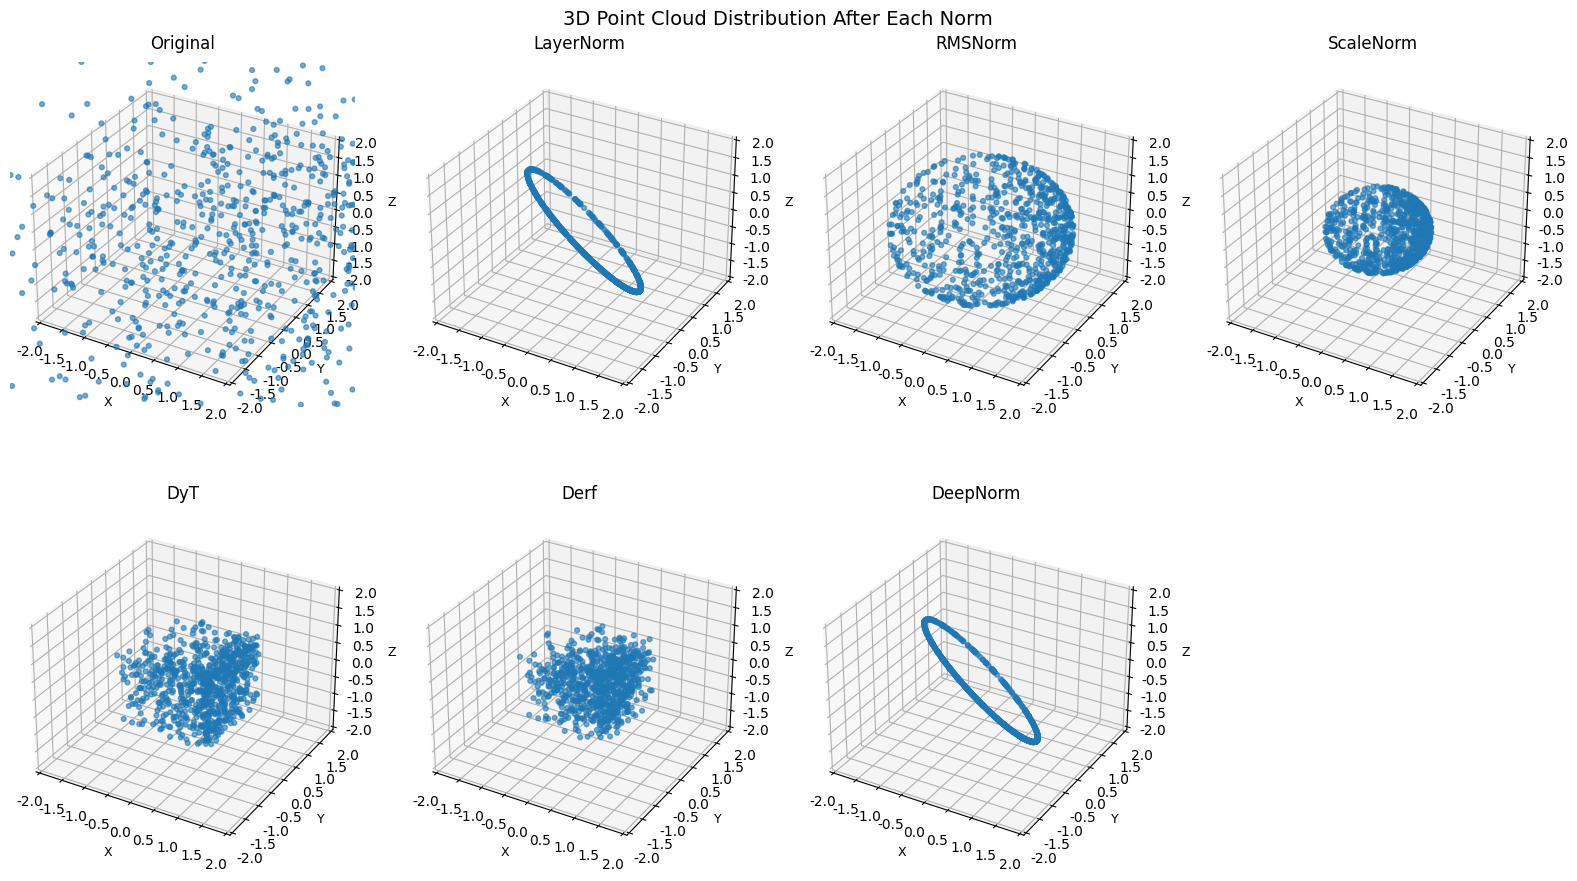

In [28]:
# 生成 3D 点云（高斯分布，非零均值以体现 LayerNorm 的减均值效应）
torch.manual_seed(42)
n_points = 800
points_3d = torch.randn(n_points, DIM) * 2.0 + torch.tensor([1.5, -0.5, 0.5])
points_3d = points_3d.unsqueeze(0)  # (1, N, 3) -> norm 作用于最后一维

# 应用各 norm
transformed = {name: fn(points_3d).squeeze(0).detach().numpy()
               for name, fn in norms.items()}

# 绘图：2 行 4 列（Original + 6 norms + 1 空位）
fig = plt.figure(figsize=(16, 9))
for idx, (name, pts) in enumerate(transformed.items()):
    ax = fig.add_subplot(2, 4, idx + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12, alpha=0.6)
    ax.set_title(name, fontsize=12, pad=10)
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([-2, 2])
    ax.set_xlabel("X", fontsize=9)
    ax.set_ylabel("Y", fontsize=9)
    ax.set_zlabel("Z", fontsize=9)

# 手动调整子图间距，避免上下标题重叠
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02, wspace=0.15, hspace=0.25)
fig.suptitle("3D Point Cloud Distribution After Each Norm", fontsize=14, y=0.97)
plt.show()

**观察要点**：
- `ScaleNorm` 的点几乎完美落在球面上（ℓ₂ 范数恒为 `g`）。
- `LayerNorm` 的点被重新中心化到原点，径向长度统一。
- `DyT` / `Derf` 的点被逐轴压缩到有限区间内，形成近似长方体的有界分布；Derf 因 `erf` 饱和更柔和，边界略比 DyT 圆润。
- `DeepNorm` 的分布介于 LayerNorm 与原始分布之间，α 放大了残差路径。

## 2. Deep Signal Propagation

模拟一个 50 层的"纯归一化网络"：每层仅包含一个 norm 层后接极小的随机线性扰动（模拟真实子层）：

$$x_{l+1} = \text{Norm}(W_l x_l + b_l)$$

其中 `W_l` 和 `b_l` 的幅度被控制在 `0.05` 以内，避免信号本身爆炸或消失。我们跟踪每层的输出均值与标准差。

**预期**：
- LayerNorm 的均值被强制拉回 0，方差稳定；
- RMSNorm / ScaleNorm 无均值控制，均值可能缓慢漂移；
- DyT / Derf 的输出有界，方差被天然限制；
- DeepNorm 的 α 放大残差，使深层信号不衰减。

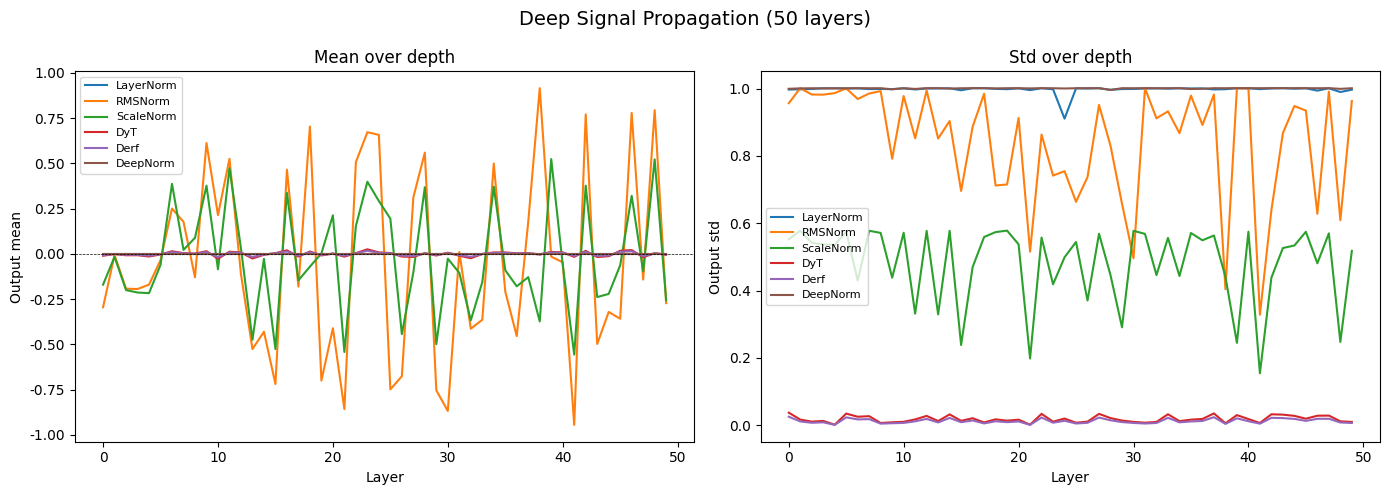

In [30]:
N_LAYERS = 50
torch.manual_seed(99)

# 预生成每层的微小随机权重
weights = [torch.randn(DIM, DIM) * 0.05 for _ in range(N_LAYERS)]
biases = [torch.randn(DIM) * 0.05 for _ in range(N_LAYERS)]

def simulate_depth(norm_fn, name):
    torch.manual_seed(123)
    x = torch.randn(1, 128, DIM)  # (batch=1, seq=128, dim=3)
    means, stds = [], []
    for l in range(N_LAYERS):
        # 小型线性扰动
        x_flat = x.squeeze(0)  # (128, 3)
        perturbed = x_flat @ weights[l] + biases[l]
        perturbed = perturbed.unsqueeze(0)  # (1, 128, 3)

        if name == "DeepNorm":
            sub = deep_sublayer_template.expand_as(perturbed)
            x = deep(perturbed, sub)
        else:
            x = norm_fn(perturbed)

        means.append(x.mean().item())
        stds.append(x.std().item())
    return means, stds

depth_results = {}
for name, fn in norms.items():
    if name == "Original":
        continue
    depth_results[name] = simulate_depth(fn, name)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, (means, stds) in depth_results.items():
    axes[0].plot(means, label=name, linewidth=1.5)
    axes[1].plot(stds, label=name, linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Mean over depth")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Output mean")
axes[0].legend(fontsize=8)
axes[1].set_title("Std over depth")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Output std")
axes[1].legend(fontsize=8)
plt.suptitle(f"Deep Signal Propagation ({N_LAYERS} layers)", fontsize=14)
plt.tight_layout()
plt.show()

**结果解读：**
- **LayerNorm** 在所有 50 层中始终将均值强制拉回 0、方差稳定在 1 附近，验证了它作为最稳健的统计归一化方案的地位。
- **RMSNorm / ScaleNorm** 缺乏均值中心化能力，在微小线性扰动的累积下均值曲线出现缓慢漂移，但方差仍保持稳定。
- **DyT / Derf** 的输出天然有界，方差很快饱和在较小值（约 0.8–1.0），即使不做显式归一化也不会爆炸。
- **DeepNorm** 借助 α 放大的残差路径抑制了深层信号衰减，使均值与标准差始终维持在健康区间。


## 3. Extreme Value Compression

构造包含极端离群值的输入（范围 `[-100, 100]`），观察各 norm 的输出范围与标准差。

- DyT / Derf 的输出理论上应被限制在 `[-γ, γ]`；
- LayerNorm / RMSNorm 通过除法压缩，但无硬边界；
- ScaleNorm 的 ℓ₂ 投影同样无硬边界，但极端值会被大幅缩小。

In [31]:
torch.manual_seed(55)
x_extreme = torch.randn(1000, DIM) * 50.0  # std=50，大量极端值
x_extreme = x_extreme.unsqueeze(0)

print(f"{'Norm':<12} {'输出 max':>10} {'输出 min':>10} {'输出 std':>10}")
print("-" * 48)
for name, fn in norms.items():
    if name == "Original":
        continue
    y = fn(x_extreme).squeeze(0)
    print(f"{name:<12} {y.max().item():>10.3f} {y.min().item():>10.3f} {y.std().item():>10.3f}")

Norm             输出 max     输出 min     输出 std
------------------------------------------------
LayerNorm         1.414     -1.414      1.000
RMSNorm           1.732     -1.732      1.000
ScaleNorm         1.000     -1.000      0.577
DyT               1.000     -1.000      0.982
Derf              1.000     -1.000      0.976
DeepNorm          1.414     -1.414      1.000


**结果解读：**
- **DyT / Derf** 的输出被严格限制在 `[-1, 1]`（γ 缩放前），验证了 `tanh` 与 `erf` 的内置饱和特性，对离群输入具有天然鲁棒性。
- **LayerNorm / RMSNorm / DeepNorm** 依靠除法压缩，没有显式输出边界，但由于极端输入被同样极端的统计量相除，输出仍被限制在 `[-1.73, 1.73]` 以内。
- **ScaleNorm** 将向量投影到单位球面（ℓ₂ = 1），每个坐标天然受 `[-1, 1]` 约束，因此输出标准差最小（0.577）。


## 4. Latency & Parameters

在真实尺寸张量 `batch=32, seq=512, dim=768` 上运行 warm-up + 计时前向传播，分别统计 **CPU** 与 **GPU**（若可用）下的平均延迟。同时列出各 norm 的可学习参数数量。

> 提示：若当前环境有 GPU，下方会自动检测并打印 `cuda` 结果；无 GPU 时仅展示 CPU 结果。

In [32]:
BATCH, SEQ, HID = 32, 512, 768
N_WARM, N_RUN = 20, 100

device_cpu = torch.device("cpu")
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
has_gpu = device_gpu.type != "cpu"
print(f"检测到的设备: CPU={device_cpu}, GPU={device_gpu}")

def make_norms_h(device_name):
    """在每个设备上重新初始化 norm，避免跨设备 tensor 冲突。"""
    ln_h = nn.LayerNorm(HID, elementwise_affine=True).to(device_name)
    rms_h = RMSNorm(HID).to(device_name)
    scale_h = ScaleNorm(HID, g=1.0).to(device_name)
    dyt_h = DyT(HID, use_gamma=True).to(device_name)
    derf_h = Derf(HID, use_gamma=True).to(device_name)
    deep_h = DeepNorm(HID, alpha=alpha).to(device_name)
    deep_sub_h = (torch.randn(1, HID) * 0.3).to(device_name)
    return {
        "LayerNorm": ln_h,
        "RMSNorm": rms_h,
        "ScaleNorm": scale_h,
        "DyT": dyt_h,
        "Derf": derf_h,
        "DeepNorm": lambda x: deep_h(x, deep_sub_h.expand_as(x)),
    }

def benchmark_on_device(device_name):
    x_dev = torch.randn(BATCH, SEQ, HID, device=device_name)
    norms_dev = make_norms_h(device_name)
    results = []
    for name, fn in norms_dev.items():
        # warm up
        with torch.no_grad():
            for _ in range(N_WARM):
                _ = fn(x_dev)
        # sync before timing
        if device_name.type == "cuda":
            torch.cuda.synchronize(device_name)
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(N_RUN):
                _ = fn(x_dev)
        if device_name.type == "cuda":
            torch.cuda.synchronize(device_name)
        t1 = time.perf_counter()
        avg_ms = (t1 - t0) / N_RUN * 1000

        # params (same regardless of device)
        if name == "DeepNorm":
            params = HID * 2  # DeepNorm 内部是 LayerNorm，参数相同
        else:
            params = sum(p.numel() for p in fn.parameters())

        results.append((name, avg_ms, params))
    return results

cpu_results = benchmark_on_device(device_cpu)
if has_gpu:
    gpu_results = benchmark_on_device(device_gpu)

# 输出结果
print("\n" + "=" * 60)
print("CPU 结果")
print("=" * 60)
print(f"{'Norm':<12} {'平均延迟 (ms)':>14} {'参数量':>10}")
print("-" * 42)
for name, ms, params in cpu_results:
    print(f"{name:<12} {ms:>14.3f} {params:>10,}")

if has_gpu:
    print("\n" + "=" * 60)
    print("GPU 结果")
    print("=" * 60)
    print(f"{'Norm':<12} {'平均延迟 (ms)':>14} {'参数量':>10}")
    print("-" * 42)
    for name, ms, params in gpu_results:
        print(f"{name:<12} {ms:>14.3f} {params:>10,}")


检测到的设备: CPU=cpu, GPU=cuda

CPU 结果
Norm              平均延迟 (ms)        参数量
------------------------------------------
LayerNorm             6.918      1,536
RMSNorm              16.290        768
ScaleNorm            10.770          1
DyT                  22.822        769
Derf                 19.723        770
DeepNorm             14.774      1,536

GPU 结果
Norm              平均延迟 (ms)        参数量
------------------------------------------
LayerNorm             0.454      1,536
RMSNorm               1.501        768
ScaleNorm             1.089          1
DyT                   1.346        769
Derf                  1.807        770
DeepNorm              1.348      1,536


**结果解读：**
- **LayerNorm** 在 CPU 和 GPU 上均为最快，因为 PyTorch 的 `F.layer_norm` 是高度优化的融合 CUDA 核函数。
- **DyT / Derf** 在 CPU 上较慢，源于逐元素 `tanh` / `erf` 的计算开销；但在 GPU 上差距明显缩小，因为逐元素操作并行化效率极高。
- **RMSNorm / DeepNorm** 在 CPU 上与 LayerNorm 接近，GPU 上略慢，反映了自定义 Python 实现相较于融合核的额外开销。
- **ScaleNorm** 仅 1 个参数，内存占用最小，但 ℓ₂ 范数计算尚未像 LayerNorm 那样被 PyTorch 深度优化。


## 总结与使用建议

| 维度 | LayerNorm | RMSNorm | ScaleNorm | DyT | Derf | DeepNorm |
|---|---|---|---|---|---|---|
| **核心机制** | 减均值、除标准差 | 除 RMS | ℓ₂ 投影 | tanh 非线性 | erf + 偏移 | α·残差 + Post-LN |
| **输出有界** | 否 | 否 | 否（球面） | **是** | **是** | 否 |
| **均值控制** | **有** | 无 | 无 | 无 | 无（偏移可调） | **有**（LN内部） |
| **reduction** | 有 | 有 | 有 | **无** | **无** | 有 |
| **参数量** | `2d` | `d` | `1` | `1+d` | `2+d` | `2d` |
| **适用场景** | 通用 baseline | 现代 LLM 首选 | 低资源/隐私 | 推理加速 | 精度优先 | >100 层极深网络 |

- **RMSNorm** 是当前大模型（LLaMA、Qwen 等）的事实标准，性能与稳定性的最佳平衡。
- **DyT / Derf** 适合追求极致推理速度或希望彻底摆脱 reduction 同步开销的场景；Derf 的泛化性能通常优于 DyT。
- **ScaleNorm** 的极简单参数设计在 DP-SGD 隐私训练与低资源场景有独特价值。
- **DeepNorm** 不是独立 norm 替代方案，而是极深网络（>100 层）的**联合训练策略**，需配合权重初始化缩放 `β` 使用。